In [10]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [2]:

df = pd.read_parquet("../data/processed/flight_data_model_ready.parquet")

df.head()

,departure_hour,DayOfWeek,DistanceGroup,airport_hour_flights,previous_arrival_delay,previous_delay_positive,is_first_flight_of_day,delay_propagation
0,17,7,4,408,0.0,0,1,0
1,12,1,3,109,0.0,0,1,0
2,15,1,3,483,-16.0,0,0,0
3,18,1,3,53,-8.0,0,0,0
4,20,1,3,10,26.0,1,0,0


## OLD MODEL (based on v1 features)
## kept for reference

In [3]:
X = df.drop("delay_propagation", axis=1)
y = df["delay_propagation"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (446972, 7)
Test size: (111743, 7)


In [5]:
categorical_features = ["DayOfWeek", "DistanceGroup"]

numerical_features = [
    "departure_hour",
    "airport_hour_flights",
    "previous_arrival_delay",
    "previous_delay_positive",
    "is_first_flight_of_day"
]

In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)

In [7]:
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

c:\Users\Abdul Basit\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['DayOfWeek',
                                                   'DistanceGroup']),
                                                 ('num', 'passthrough',
                                                  ['departure_hour',
                                                   'airport_hour_flights',
                                                   'previous_arrival_delay',
                                                   'previous_delay_positive',
                                                   'is_first_flight_of_day'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [17]:
y_pred_log = log_model.predict(X_test)
y_proba_log = log_model.predict_proba(X_test)[:, 1]

print("Logistic Regression: \n")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_log))

Logistic Regression: 

Accuracy: 0.8948301012143938
Precision: 0.7056810403832992
Recall: 0.22818148284765769
ROC-AUC: 0.8765309120180579


In [16]:
print("\nClassification Report Logistic Regression:\n")
print(classification_report(y_test, y_pred_log))


Classification Report Logistic Regression:

              precision    recall  f1-score   support

           0       0.90      0.99      0.94     98188
           1       0.71      0.23      0.34     13555

    accuracy                           0.89    111743
   macro avg       0.80      0.61      0.64    111743
weighted avg       0.88      0.89      0.87    111743



In [10]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['DayOfWeek',
                                                   'DistanceGroup']),
                                                 ('num', 'passthrough',
                                                  ['departure_hour',
                                                   'airport_hour_flights',
                                                   'previous_arrival_delay',
                                                   'previous_delay_positive',
                                                   'is_first_flight_of_day'])])),
                ('classifier',
                 RandomForestClassifier(n_jobs=-1, random_state=42))])

In [14]:
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]
print("Random Forest: \n")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

Random Forest: 

Accuracy: 0.9058106548061176
Precision: 0.6347864768683275
Recall: 0.5263740317226115
ROC-AUC: 0.8851025946100555


In [15]:

print("\nClassification Report Random Forest:\n")
print(classification_report(y_test, y_pred_rf))


Classification Report Random Forest:

              precision    recall  f1-score   support

           0       0.94      0.96      0.95     98188
           1       0.63      0.53      0.58     13555

    accuracy                           0.91    111743
   macro avg       0.79      0.74      0.76    111743
weighted avg       0.90      0.91      0.90    111743



In [13]:
feature_names = (
    log_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = rf_model.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

importance_df.head(10)

,feature,importance
18,num__previous_arrival_delay,0.458430
17,num__airport_hour_flights,0.248609
19,num__previous_delay_positive,0.120705
16,num__departure_hour,0.103511
20,num__is_first_flight_of_day,0.006296
7,cat__DistanceGroup_3,0.006141
6,cat__DistanceGroup_2,0.005593
4,cat__DayOfWeek_6,0.005502
5,cat__DayOfWeek_7,0.005269
0,cat__DayOfWeek_2,0.005035


## Modeling with Refined Feature Set (v2)

In [2]:
df = pd.read_parquet("../data/processed/flight_data_model_ready_v2.parquet")

X = df.drop("delay_propagation", axis=1)
y = df["delay_propagation"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (446972, 8)
Test size: (111743, 8)


In [3]:
categorical_features = ["DayOfWeek", "DistanceGroup"]

numerical_features = [
    "departure_hour",
    "airport_hour_flights",
    "previous_arrival_delay",
    "previous_delay_positive",
    "departure_delay",
    "departure_delay_15plus"
]

In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical_features),
        ("num", StandardScaler(), numerical_features)
    ]
)

In [12]:
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    ))
])

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_proba_log = log_model.predict_proba(X_test)[:, 1]


In [19]:

print("Logistic Regression (v2):\n")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_log))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))


Logistic Regression (v2):

Accuracy: 0.8983828964677877
Precision: 0.5476437976437977
Recall: 0.932792327554408
ROC-AUC: 0.9576460814856381

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.89      0.94     98188
           1       0.55      0.93      0.69     13555

    accuracy                           0.90    111743
   macro avg       0.77      0.91      0.81    111743
weighted avg       0.94      0.90      0.91    111743



In [15]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]


In [18]:
print("Random Forest (v2):\n")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))


print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest (v2):

Accuracy: 0.9392803128607609
Precision: 0.773513251454428
Recall: 0.7062338620435263
ROC-AUC: 0.9722141861207485

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.97      0.97     98188
           1       0.77      0.71      0.74     13555

    accuracy                           0.94    111743
   macro avg       0.87      0.84      0.85    111743
weighted avg       0.94      0.94      0.94    111743



In [21]:
# Get feature names after preprocessing
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

# Get importance from classifier
importances = rf_model.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

importance_df.head(15)

,feature,importance
20,num__departure_delay,0.372890
21,num__departure_delay_15plus,0.256843
18,num__previous_arrival_delay,0.149698
16,num__departure_hour,0.066270
17,num__airport_hour_flights,0.063202
19,num__previous_delay_positive,0.054532
7,cat__DistanceGroup_3,0.003357
6,cat__DistanceGroup_2,0.003066
0,cat__DayOfWeek_2,0.003040
5,cat__DayOfWeek_7,0.002911


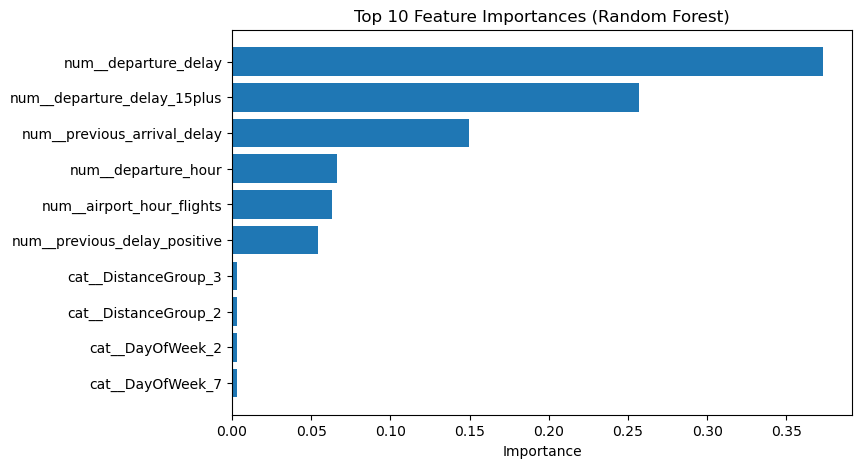

In [22]:
import matplotlib.pyplot as plt

top_features = importance_df.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.show()

# Modeling Insights – Delay Propagation Prediction

## 1. Objective of Modeling Stage

The goal of this stage was to evaluate whether delay propagation can be predicted using operational features available before departure.

The task was framed as a binary classification problem:

- 1 → Delay propagation occurred  
- 0 → No delay propagation  

Multiple models were tested to compare performance and understand feature impact.

---

## 2. Models Evaluated

Two main models were used:

- Logistic Regression  
- Random Forest  

The first version used basic engineered features.  
The second version (refined model) added improved aircraft rotation logic and departure delay features.

---

## 3. Baseline vs Refined Model

### Baseline Model

The initial model showed moderate performance.  
Random Forest performed better than Logistic Regression, but recall for propagation was limited.

This indicated that features were not strong enough.

---

### Refined Model (v2)

After improving feature engineering (especially adding departure delay and better aircraft rotation features), performance improved significantly.

#### Logistic Regression (v2)

- High recall (~93%)
- Lower precision (~55%)
- ROC-AUC ~0.96

This model detects most propagation cases but produces more false positives.

#### Random Forest (v2)

- Accuracy ~94%
- Precision ~77%
- Recall ~71%
- ROC-AUC ~0.97

This model provides a much better balance between detecting delays and avoiding false alarms.

Random Forest was selected as the final model.

---

## 4. Feature Importance Analysis

Feature importance revealed:

1. **Departure delay** (strongest factor)
2. **Departure delay ≥ 15 minutes**
3. **Previous arrival delay**
4. Departure hour
5. Airport hourly traffic

Day of week and distance group had very low importance.

---

## 5. Key Findings

### A. Departure Delay is the Strongest Driver

If a flight is already delayed at departure, the chance of propagation increases significantly.

This aligns with real-world airline operations.

---

### B. Aircraft Rotation Matters

Previous arrival delay strongly influences the next flight.

This confirms the hypothesis that delay propagation is primarily driven by aircraft rotation effects.

---

### C. Time-of-Day Has Moderate Influence

Flights later in the day show higher risk, likely due to accumulated delays across rotations.

---

### D. Airport Congestion Has Limited Impact

The congestion proxy (departures per hour) showed weaker influence than expected.

This suggests aircraft-level factors are more important than airport-level volume alone.

---

## 6. Model Interpretation

The high ROC-AUC (~0.97) indicates strong ability to separate propagation vs non-propagation flights.

Random Forest balances precision and recall effectively.

Logistic Regression is more aggressive in detecting propagation but produces more false positives.

---


## 7. Overall Findings

The refined feature set significantly improved model performance.

Aircraft-level and departure-level variables contributed most to predictive power.

The models demonstrate strong ability to distinguish between propagation and non-propagation cases, as reflected by high ROC-AUC values.

---

## 8. Limitations

- Real-time weather conditions were not directly modeled.
- Turnaround buffer time is not explicitly available.
- Crew scheduling constraints are not included.
- Congestion is approximated rather than measured dynamically.
- The model predicts occurrence, not severity of delay.

These factors may influence real-world propagation but are outside the scope of this dataset.

---

## 9. Conclusion

Feature engineering played a central role in improving predictive performance.

The analysis highlights that delay propagation is more strongly influenced by aircraft rotation and departure conditions than by weekly schedule patterns or route type.

The results provide both predictive insight and operational interpretation into how delay spread occurs within airline systems.